In [19]:
import numpy as np
import pandas as pd
import utils
import matplotlib.pyplot as plt
import matplotlib.animation as manimation
import plotly.graph_objects as go
import plotly.io as pio
from typing import Callable,Any
from scipy.spatial.transform import Rotation,Slerp
from elastica.modules import BaseSystemCollection,Constraints,Forcing,Damping,CallBacks
from elastica.rod.cosserat_rod import CosseratRod
from elastica.boundary_conditions import OneEndFixedBC,ConstraintBase
from elastica.external_forces import GravityForces
from elastica.dissipation import AnalyticalLinearDamper
from elastica.callback_functions import CallBackBaseClass,defaultdict
from elastica.timestepper.symplectic_steppers import PositionVerlet
from elastica.timestepper import integrate

In [20]:
class Simulator(
    BaseSystemCollection,Constraints,Forcing,Damping,CallBacks
):
    pass

In [21]:
df=pd.read_csv('../data/2810/p1-case3.csv')
pts=df.iloc[10:,2:].reset_index(drop=True)
length=utils.length(pts.values)

In [22]:
simulator=Simulator()
n_elements=100 
base_length=length 
base_radius=2.43 
start_pos=df.iloc[5,2:].values.astype(float)
direction=np.array([0.0,1.0,0.0]) 
normal=np.array([0.0,0.0,1.0]) 
density=1.23e-6 
youngs_modulus=0.003605
shear_modulus=youngs_modulus/(2.0*(1.0+0.49))

tube=CosseratRod.straight_rod(
    n_elements=n_elements,
    start=start_pos,
    direction=direction,
    normal=normal,
    base_length=base_length,
    base_radius=base_radius,
    density=density,
    youngs_modulus=youngs_modulus,
    shear_modulus=shear_modulus
)

simulator.append(tube)

In [23]:
simulator.add_forcing_to(tube).using(
    GravityForces,
    acc_gravity=np.array([0.0,0.0,-1e-2])
)

In [24]:
dmp_const=0.3
dt=1e-3
simulator.dampen(tube).using(
    AnalyticalLinearDamper,
    damping_constant=dmp_const,
    time_step=dt
)
print('Added dampner to the simulation')

Added dampner to the simulation


In [25]:
simulator.constrain(tube).using(
    OneEndFixedBC,
    constrained_position_idx=(0,),
    constrained_director_idx=(0,)
)
print('Added FixedBC')

Added FixedBC


In [26]:
class EndpointKinematicConstraint(ConstraintBase):
    def __init__(self,
                 node_idx: int,
                 elem_idx: int,
                 target_position_function: Callable[[float],np.ndarray],
                 target_director_function: Callable[[float],np.ndarray],
                 target_velocity_function: Callable[[float],np.ndarray],
                 target_omega_function: Callable[[float],np.ndarray],
                 **kwargs):
        super().__init__(**kwargs)
        self.node_idx=node_idx
        self.elem_idx=elem_idx        
        self.pos_func=target_position_function
        self.dir_func=target_director_function
        self.vel_func=target_velocity_function
        self.omg_func=target_omega_function

    def constrain_values(self,system: Any,time: float) -> None:
        target_pos=self.pos_func(time)
        target_dir=self.dir_func(time)
        system.position_collection[...,self.node_idx]=target_pos
        system.director_collection[...,self.elem_idx]=target_dir
        
    def constrain_rates(self,system: Any,time: float) -> None:
        target_vel=self.vel_func(time)
        target_omg=self.omg_func(time)
        system.velocity_collection[...,self.node_idx]=target_vel
        system.omega_collection[...,self.elem_idx]=target_omg

In [27]:
class TrajectoryRamp:
    def __init__(self,
                 start_pos: np.ndarray,
                 end_pos: np.ndarray,
                 start_dir: np.ndarray,
                 end_dir: np.ndarray,
                 ramp_time: float):
        
        self.start_pos=start_pos
        self.end_pos=end_pos
        self.pos_diff=end_pos - start_pos        
        self.ramp_time=ramp_time
        self.const_vel=self.pos_diff / ramp_time
        key_rots=Rotation.from_matrix([start_dir,end_dir])
        key_times=[0,ramp_time]
        self.slerp=Slerp(key_times,key_rots)
        self.const_omg=np.zeros((3,))
        
    def _get_ramp_factor(self,time: float) -> float:
        if time < 0:
            return 0.0
        elif time > self.ramp_time:
            return 1.0
        else:
            return time / self.ramp_time

    def get_position(self,time: float) -> np.ndarray:
        factor=self._get_ramp_factor(time)
        return self.start_pos + self.pos_diff * factor

    def get_director(self,time: float) -> np.ndarray:
        clamped_time=max(0,min(time,self.ramp_time))
        return self.slerp(clamped_time).as_matrix()

    def get_velocity(self,time: float) -> np.ndarray:
        if 0 < time <= self.ramp_time:
            return self.const_vel
        else:
            return np.zeros((3,))

    def get_omega(self,time: float) -> np.ndarray:
        if 0 < time <= self.ramp_time:
            return self.const_omg
        else:
            return np.zeros((3,))

In [28]:
class TrajectoryCircle:
    def __init__(self,center: np.ndarray,radius: float,freq: float):
        self.center=center
        self.radius=radius
        self.omega_val=2.0 * np.pi * freq

    def get_position(self,time: float) -> np.ndarray:
        x=self.center + self.radius * np.cos(self.omega_val * time)
        y=self.center + self.radius * np.sin(self.omega_val * time)
        return np.array([x,y,self.center])
    
    def get_velocity(self,time: float) -> np.ndarray:
        vx=-self.radius * self.omega_val * np.sin(self.omega_val * time)
        vy=self.radius * self.omega_val * np.cos(self.omega_val * time)
        return np.array([vx,vy,0.0])

    def get_director(self,time: float) -> np.ndarray:
        return np.identity(3)

    def get_omega(self,time: float) -> np.ndarray:
        return np.zeros((3,))

In [29]:
init_pos=tube.position_collection[...,-1].copy()
init_dir=tube.director_collection[...,-1].copy()
tgt_pos=df.iloc[6,2:].values
tgt_dir=utils.dir_unitvectr(df.iloc[9,2:].values).T
ramp_time=350

trajectory=TrajectoryRamp(
    init_pos,tgt_pos,init_dir,tgt_dir,ramp_time
)

simulator.constrain(tube).using(
    EndpointKinematicConstraint,
    node_idx=-1,
    elem_idx=-1,
    target_position_function=trajectory.get_position,
    target_director_function=trajectory.get_director,
    target_velocity_function=trajectory.get_velocity,
    target_omega_function=trajectory.get_omega
)

In [30]:
class TubeCallback(CallBackBaseClass):
    def __init__(self,step_skip: int,callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every=step_skip
        self.callback_params=callback_params

    def make_callback(self,system: Any,time: int,current_step: int):
        if current_step % self.every == 0:
            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            self.callback_params["length"].append(system.rest_lengths.copy())
            self.callback_params["radius"].append(system.radius.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
            self.callback_params["avg_velocity"].append(system.compute_velocity_center_of_mass())
            self.callback_params["com"].append(system.compute_position_center_of_mass())
            self.callback_params["curvature"].append(system.kappa.copy())
            return

In [31]:
cb_data=defaultdict(list)
dt_intrvl=100
simulator.collect_diagnostics(tube).using(
    TubeCallback,
    step_skip=dt_intrvl,
    callback_params=cb_data
)

In [32]:
simulator.finalize()
print('Simulator finalized')

Simulator finalized


In [33]:
timestepper=PositionVerlet()
final_time=750 
total_steps=int(final_time/dt)

print("Running simulation...")
integrate(timestepper,simulator,final_time,total_steps)
print("Simulation finished.")

Running simulation...


100%|██████████| 750000/750000 [03:23<00:00, 3690.95it/s]

Final time of simulation is :  749.9999999857208
Simulation finished.


In [34]:
position_history=np.array(cb_data["position"])
final_rod_position=position_history[-1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=final_rod_position[0,:],y=final_rod_position[1,:],z=final_rod_position[2,:],mode='lines',name='Final position',line=dict(color='darkslategray',width=6)))
fig.update_layout(title='3D Projection',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),font=dict(size=15,family='Times New Roman'),autosize=False,height=700,width=1200,legend=dict(x=0.02,y=0.98),margin=dict(l=20,r=20,t=40,b=20))
fig.update_scenes(camera_projection_type='orthographic')
fig.show()

In [35]:
df=pd.read_csv('../data/2810/p1-case3.csv')
prt=df.iloc[10:,2:].reset_index(drop=True)
p0=df.iloc[5,2:].values.astype(float)   
p1=df.iloc[6,2:].values.astype(float)   
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]   
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]   
siml=pd.DataFrame(final_rod_position.T,columns=['X','Y','Z'])
fig=utils.plotter(prt.values,p0,p1,u0,u1,x_label='Prototype',spl1=siml.values,spl1_label='Simulated',cne=6,intr='d') 
a=df.iloc[59,2:] 
b=siml.iloc[50] 
fig.add_trace(go.Scatter3d(x=[a[0],b[0]],y=[a[1],b[1]],z=[a[2],b[2]],mode='lines',name='Error',line=dict(color='red',width=6,dash='longdash'))) 
fig.show()
pio.write_html(fig,'html/p1-case3.html')
siml.to_csv('data/p1-case3.csv',index=False)

C:\Users\Dell\AppData\Local\Temp\ipykernel_10696\1454682269.py:11: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



C:\Users\Dell\AppData\Local\Temp\ipykernel_10696\3563701167.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Dell\AppData\Local\Temp\ipykernel_10696\3563701167.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



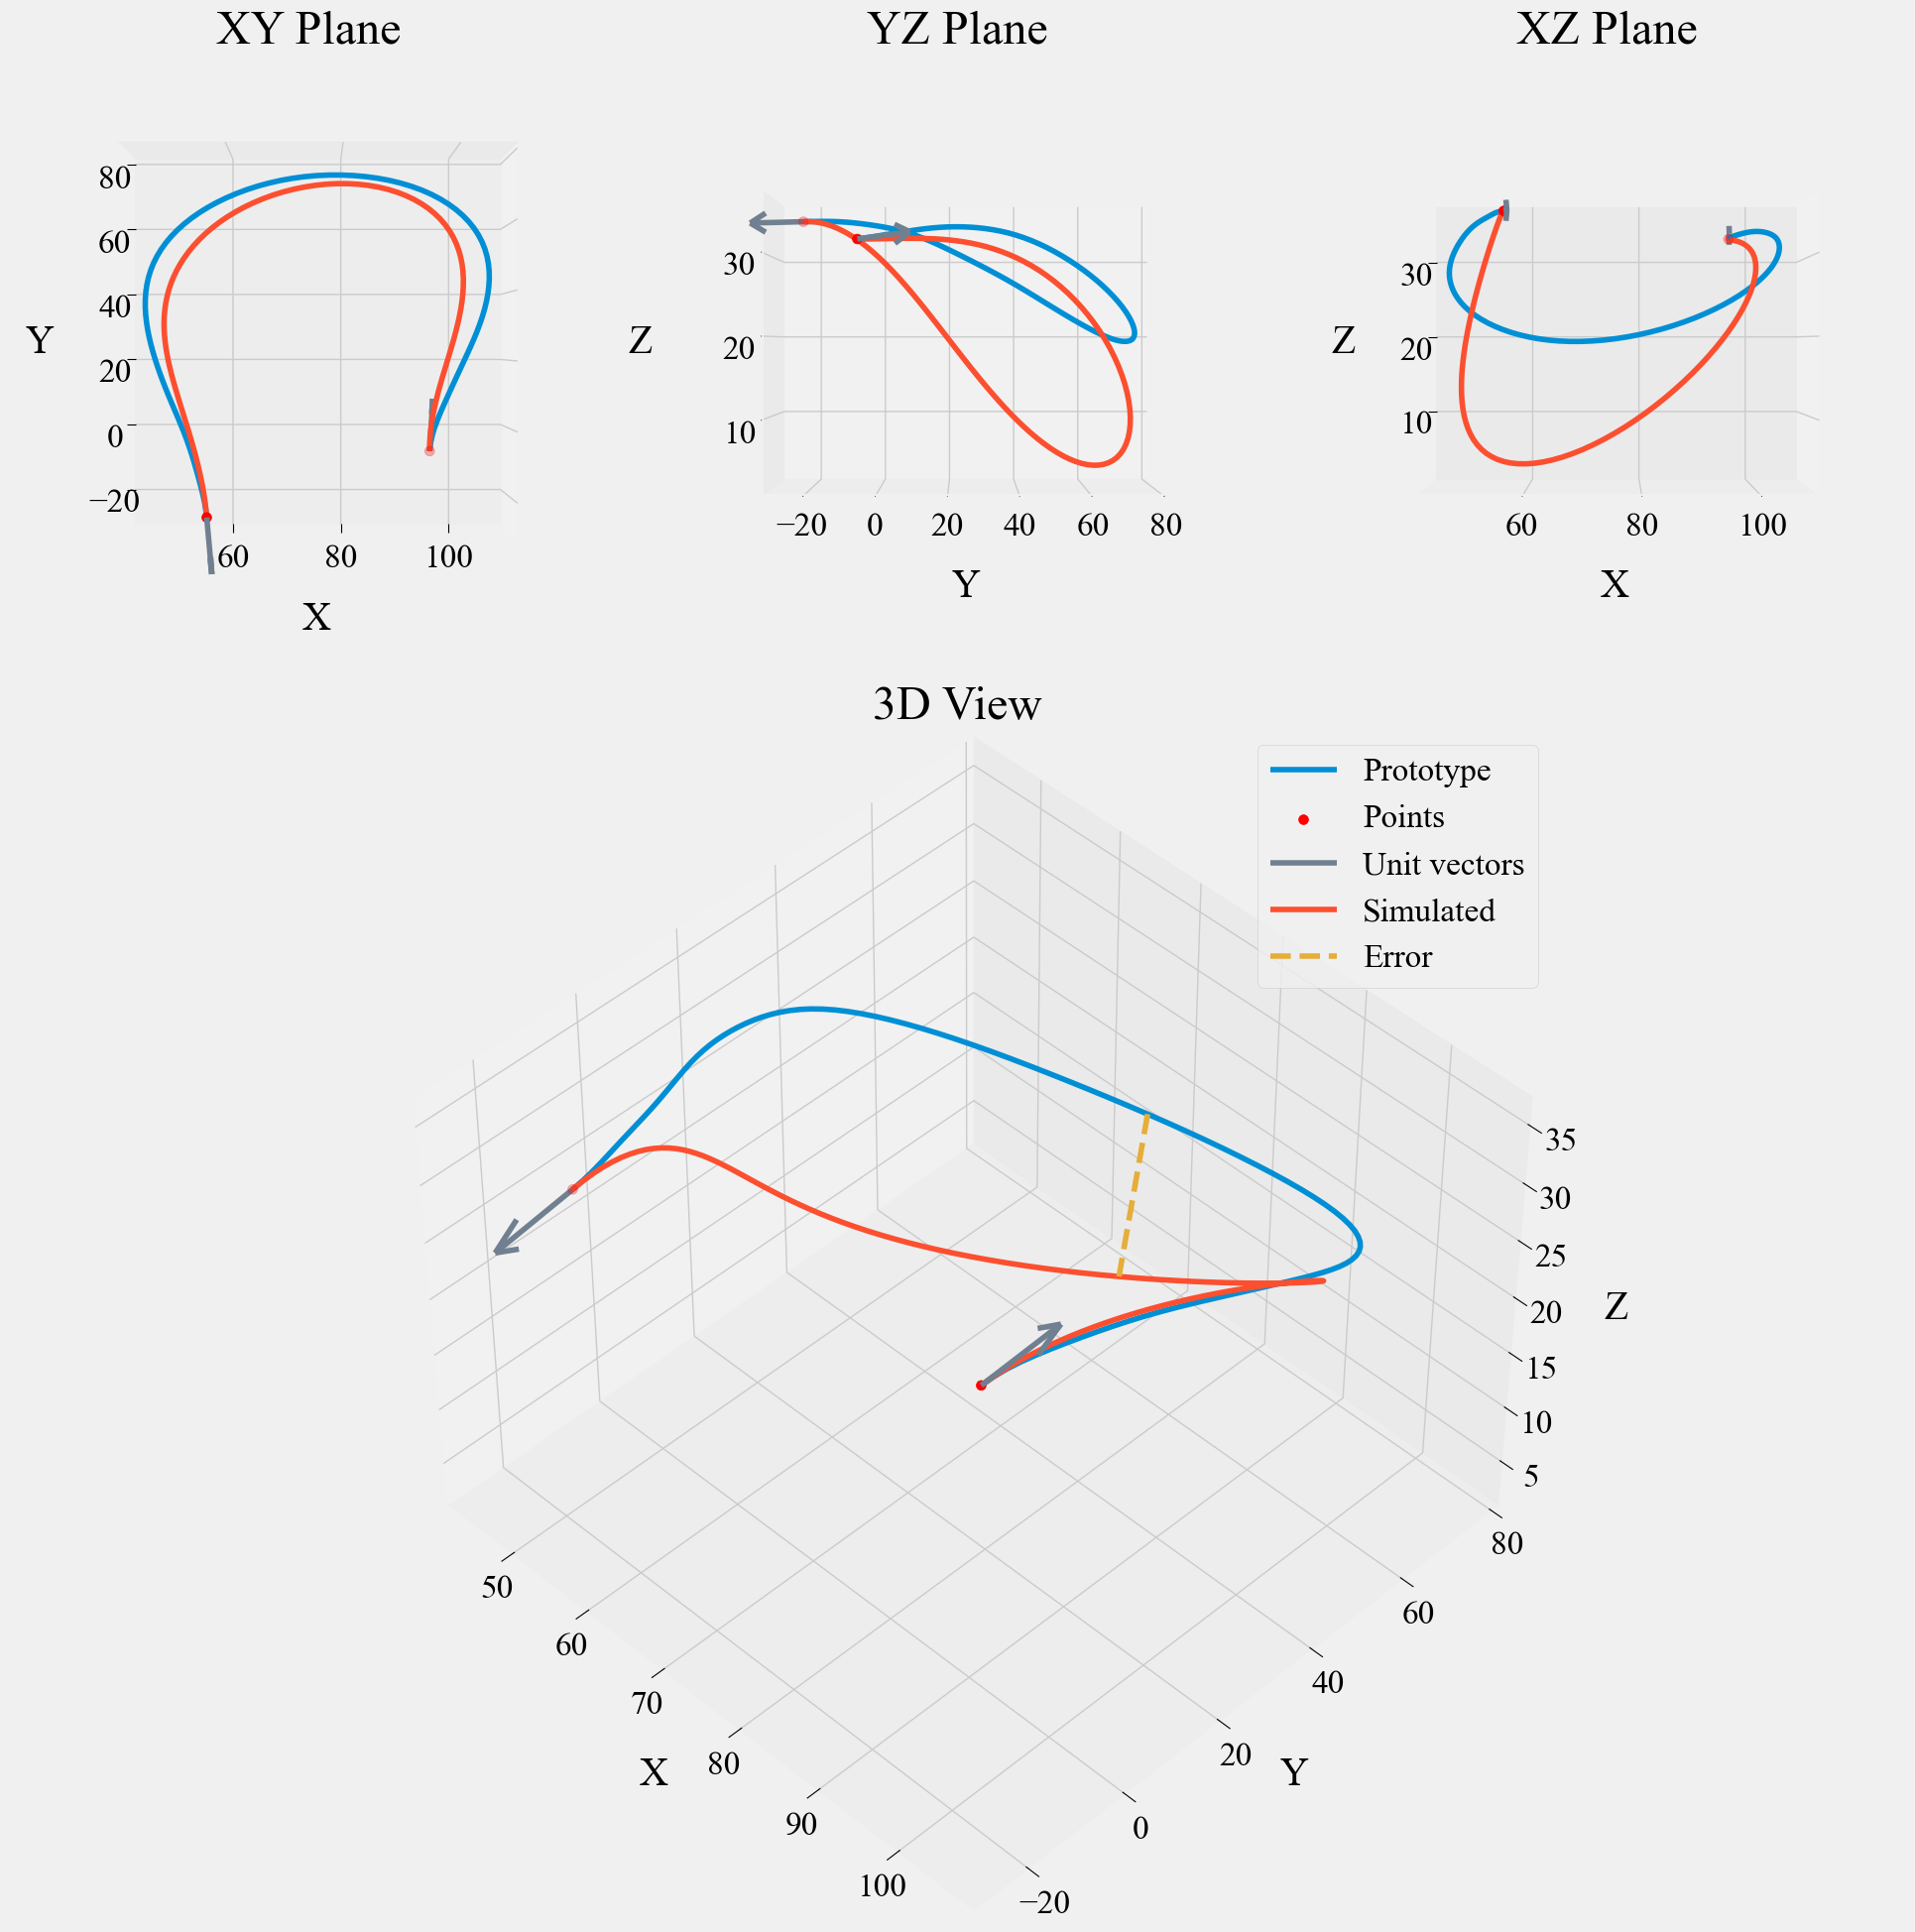

In [36]:
fig,ax1,ax2,ax3,ax4=utils.plotter(prt.values,p0,p1,u0,u1,x_label='Prototype',spl1=siml.values,spl1_label='Simulated',cne=6,intr='s')
ax4.plot([a[0],b[0]],[a[1],b[1]],[a[2],b[2]],label='Error',linestyle='--')
ax4.legend()
fig.show()